# Preprocssing Data

In [ ]:
#Libraries imported:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import xgboost as xgb
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

Implementing Feature Engineering

Preprocessing and feature engineering involve encoding categorical variables, handling missing values, normalizing numerical features, and ensuring consistency between training and test datasets for machine learning models.

In [ ]:
import pandas as pd
import numpy as np

def encode_columns(column):
    """
    Encodes categorical columns using a predefined mapping strategy.
    Converts 'Positive', 'Yes' to 1, 'Negative', 'No' to 0, and handles missing values.
    """
    column_filled = column.fillna('NA').astype(str)  # Handle missing values
    custom_mapping = {
        'Positive': 1, 'Negative': 0, 'Yes': 1, 'No': 0,
        'Not done': 2, 'NA': -1  # Special handling for missing values
    }
    return column_filled.map(custom_mapping)

def preprocess_features(df, reference_columns=None):
    """
    Preprocesses a DataFrame by handling categorical features, encoding values,
    and filling missing values. Ensures consistency with reference columns.

    Args:
        df (pd.DataFrame): The DataFrame to preprocess.
        reference_columns (list, optional): The list of final columns from training data.

    Returns:
        pd.DataFrame: The processed DataFrame with aligned columns.
    """
    # Apply mappings for specific categorical features
    mappings = {
        'dri_score': {'Low': 1, 'Intermediate': 2, 'Intermediate - TED AML case <missing cytogenetics': 2.5,
                      'High': 3, 'High - TED AML case <missing cytogenetics': 3.5, 'Very high': 4,
                      'N/A - disease not classifiable': -1, 'N/A - non-malignant indication': -2,
                      'N/A - pediatric': -2, 'TBD cytogenetics': -1, 'Missing disease status': -1},
        'psych_disturb': {'No': 0, 'Yes': 1, 'Not done': 2, 'Unknown': 3},
        'cyto_score': {'Favorable': 1, 'Intermediate': 2, 'Normal': 3, 'Other': 4,
                       'Poor': 5, 'TBD': 6, 'Not tested': 6, 'Unknown': 7},
        'diabetes': {'No': 0, 'Yes': 1, 'Not done': 2, 'Unknown': 3},
        'arrhythmia': {'No': 0, 'Yes': 1, 'Not done': 2, 'Unknown': 3},
        'vent_hist': {'No': 0, 'Yes': 1, 'Unknown': 2},
        'renal_issue': {'No': 0, 'Yes': 1, 'Not done': 2, 'Unknown': 3},
        'pulm_severe': {'No': 0, 'Yes': 1, 'Not done': 2, 'Unknown': 3},
        'hepatic_mild': {'No': 0, 'Yes': 1, 'Not done': 2, 'Unknown': 3},
        'cmv_status': {"-/+": 3, "+/-": 2, "-/-": 1, "+/+": 0, "Missing": -1},
        'conditioning_intensity': {'MAC': 5, 'RIC': 4, 'NMA': 3, 'TBD': 2,
                                   'No drugs reported': 1, 'N/A, F(pre-TED) not submitted': 0, 'Missing': -1},
        'cyto_score_detail': {'Poor': 4, 'TBD': 3, 'Not tested': 2, 'Intermediate': 1, 'Favorable': 0, 'Missing': -1},
        'graft_type': {'Bone marrow': 0, 'Peripheral blood': 1},
        'tce_match': {'Permissive': 0, 'Fully matched': 1, 'GvH non-permissive': 2, 'HvG non-permissive': 3, 'NA': -1},
        'sex_match': {'F-F': 1, 'M-M': 2, 'M-F': 3, 'F-M': 4, 'NA': -1}
    }

    # Apply mappings after filling missing values
    for col, mapping in mappings.items():
        if col in df.columns:
            df[col] = df[col].fillna('Unknown').map(mapping)

    # Fill missing numerical values using median
    numerical_cols = [
        'hla_match_c_high', 'hla_high_res_8', 'hla_low_res_6',
        'hla_high_res_6', 'hla_high_res_10', 'hla_match_dqb1_high',
        'hla_match_c_low', 'hla_match_drb1_low', 'hla_match_dqb1_low'
    ]
    for col in numerical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Handle missing values exactly as in your notebook
    df['rituximab'] = df['rituximab'].fillna(df['rituximab'].mode()[0]).map({'Yes': 1, 'No': 0})
    df['mrd_hct'] = encode_columns(df['mrd_hct'])
    df['in_vivo_tcd'] = encode_columns(df['in_vivo_tcd'])
    df['hepatic_severe'] = encode_columns(df['hepatic_severe'])
    df['prior_tumor'] = encode_columns(df['prior_tumor'])
    df['peptic_ulcer'] = encode_columns(df['peptic_ulcer'])
    df['rheum_issue'] = encode_columns(df['rheum_issue'])

    # Categorical columns that were explicitly one-hot encoded in your notebook
    categorical_cols = [
        'tbi_status', 'prim_disease_hct', 'obesity', 'prod_type',
        'ethnicity', 'race_group', 'gvhd_proph', 'tce_imm_match',
        'tce_div_match', 'donor_related', 'melphalan_dose', 'cardiac',
        'pulm_moderate'
    ]

    # Fill missing values before encoding
    for col in ['ethnicity', 'obesity']:
        if col in df.columns:
            df[col] = df[col].fillna("Missing")

    for col in ['tce_imm_match', 'tce_div_match', 'cardiac', 'pulm_moderate']:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")

    # Apply one-hot encoding
    df = pd.get_dummies(df, columns=[col for col in categorical_cols if col in df.columns], dtype=int)

    # Ensure test dataset aligns with training columns
    if reference_columns is not None:
        for col in reference_columns:
            if col not in df.columns:
                df[col] = 0  # Add missing columns
        df = df[reference_columns]  # Ensure column order matches

    # Convert True/False values to 1/0
    df = df.applymap(lambda x: 1 if x is True else (0 if x is False else x))

    return df


train_file_path = "1oCgZEJBCPQAJc9Jc2UVJtLBejSmMlR9F"
test_file_path = "1L-XeJlshuo0UkZ902VqQWw1T224BUoxZ"
train_url = f"https://drive.google.com/uc?export=download&id={train_file_path}"
test_url = f"https://drive.google.com/uc?export=download&id={test_file_path}"
train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

train_df = preprocess_features(train_df)
final_train_columns = train_df.columns.tolist()
test_df = preprocess_features(test_df, final_train_columns)

# Exploratory Data Analysis

* Mention plots from proposal
* Kaplan - Meier Algorithm for median efs time
* Kaplan-Meier Curve for sex-match

The pairplot examines relationships between EFS time, comorbidity scores, and HLA matching (hla_match_c_high)

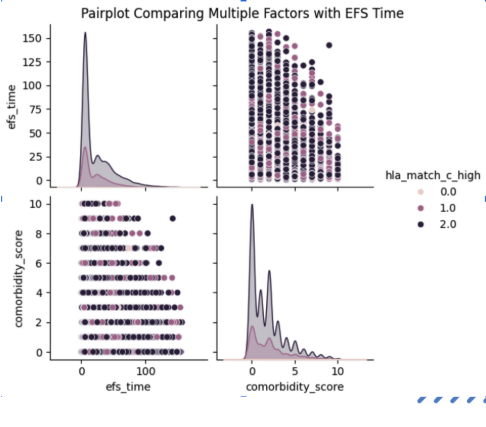


In [ ]:
# Correlation Heatmap\import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = train.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Kaplan-Meier Curve: Used to estimate survival probability over time and analyze sex-matching effects.


In [ ]:
# Install lifelines if not installed (run this in Colab or Jupyter)
# !pip install lifelines
!pip install lifelines

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv")  # Update path if needed

# Drop missing values in relevant columns
df_clean = df.dropna(subset=['sex_match', 'efs', 'efs_time'])

# Convert event-free survival event to integer (0 or 1)
df_clean['efs'] = df_clean['efs'].astype(int)

# Initialize Kaplan-Meier estimator
kmf = KaplanMeierFitter()

# Create a figure for the plot
plt.figure(figsize=(8, 5))

# Plot survival curves for each sex_match category
for category in df_clean['sex_match'].unique():
    kmf.fit(df_clean[df_clean['sex_match'] == category]['efs_time'],
            event_observed=df_clean[df_clean['sex_match'] == category]['efs'],
            label=category)
    kmf.plot()

# Customize plot
plt.title("Kaplan-Meier Survival Curve by Sex-Match")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.legend(title="Sex-Match")
plt.grid(True)

# Show plot
plt.show()

# Machine Learning Models Used:

**short blurb - what we used, why we used those models and results?


Cox Proportional Hazards Model (CoxPH): A regression model for survival analysis that provided a concordance index of ~0.66 after feature selection and regularization.

XGBoost (Accelerated Failure Time - AFT model): Used for non-linear survival predictions. It achieved a concordance index of ~0.67.

DeepSurv & GNN: Originally explored but not included in the final submission due to performance issues and time constraints.


CoxPH

In [ ]:
#Dropping folloeing columns because of their high collinearity
train_df = train_df.drop('gvhd_proph_FK+- others(not MMF,MTX)', axis=1)

# Instantiate the CoxPHFitter with a penalizer
cph = CoxPHFitter(penalizer=0.01)  # Adjust the penalizer value as needed

# Fit the model with LASSO regularization
cph.fit(train_df, duration_col='efs_time', event_col='efs')

# Print the summary (coefficients will be shrunk)
cph.print_summary()


XGBoost

In [ ]:
# XGBoost Model
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Splitting the data
X = train_clean[features]
y = train_clean["efs_time"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost Model
xgb_model = xgb.XGBRegressor(objective="survival:aft", eval_metric="aft-nloglik")
xgb_model.fit(X_train, y_train)

# Model Predictions
y_pred = xgb_model.predict(X_test)

# Evaluate Model (Using Concordance Index)
c_index_xgb = concordance_index(y_test, y_pred, train_clean.loc[y_test.index, "efs"])
print(f"Concordance Index for XGBoost Model: {c_index_xgb:.3f}")


DeepSurv




can mention trying random forests but not getting high accuracy